[2026-07-06 23:40:56] [info     ] calculate score                end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-06 23:40:56] [info     ] device                         device=cuda streams=['bar1m', 'bar5m', 'bar15m', 'bar30m']
[2026-07-06 23:40:56] [info     ] building train set             end='2023-12-31 23:59:59' instruments=120 start=2019-01-01
[2026-07-06 23:41:52] [info     ] stream built                   elapsed=56.12 mode=train samples=135388 seq_len=32 table=bigalpha_2026_stock_bar1m
[2026-07-06 23:42:07] [info     ] stream built                   elapsed=14.05 mode=train samples=135388 seq_len=32 table=bigalpha_2026_stock_bar5m
[2026-07-06 23:42:14] [info     ] stream built                   elapsed=6.47 mode=train samples=135268 seq_len=24 table=bigalpha_2026_stock_bar15m
[2026-07-06 23:42:19] [info     ] stream built                   elapsed=4.75 mode=train samples=135148 seq_len=24 table=bigalpha_2026_stock_bar30m
[2026-07-06 23:42:27] [info     ] model r

时段,IC
2024-01-15~2024-02-08,-0.0121
2024-09-24~2024-10-08,-0.0034

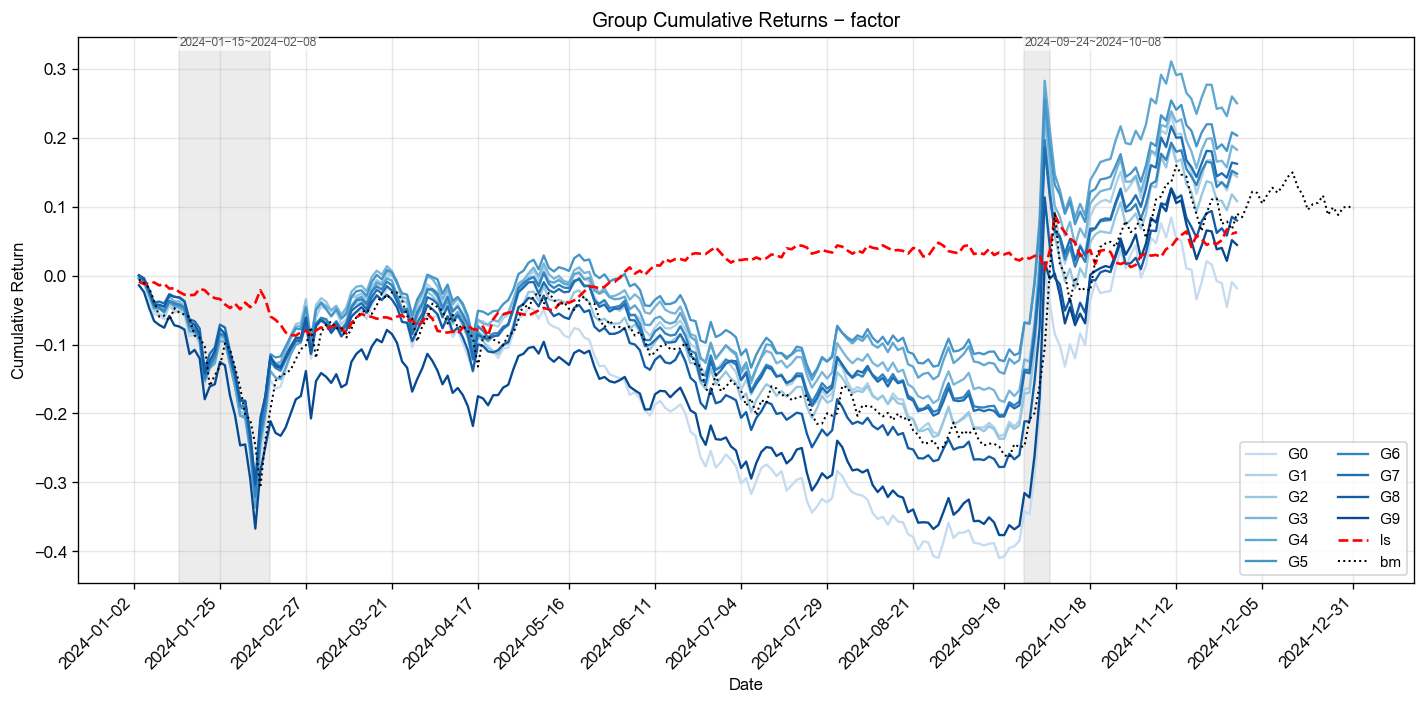
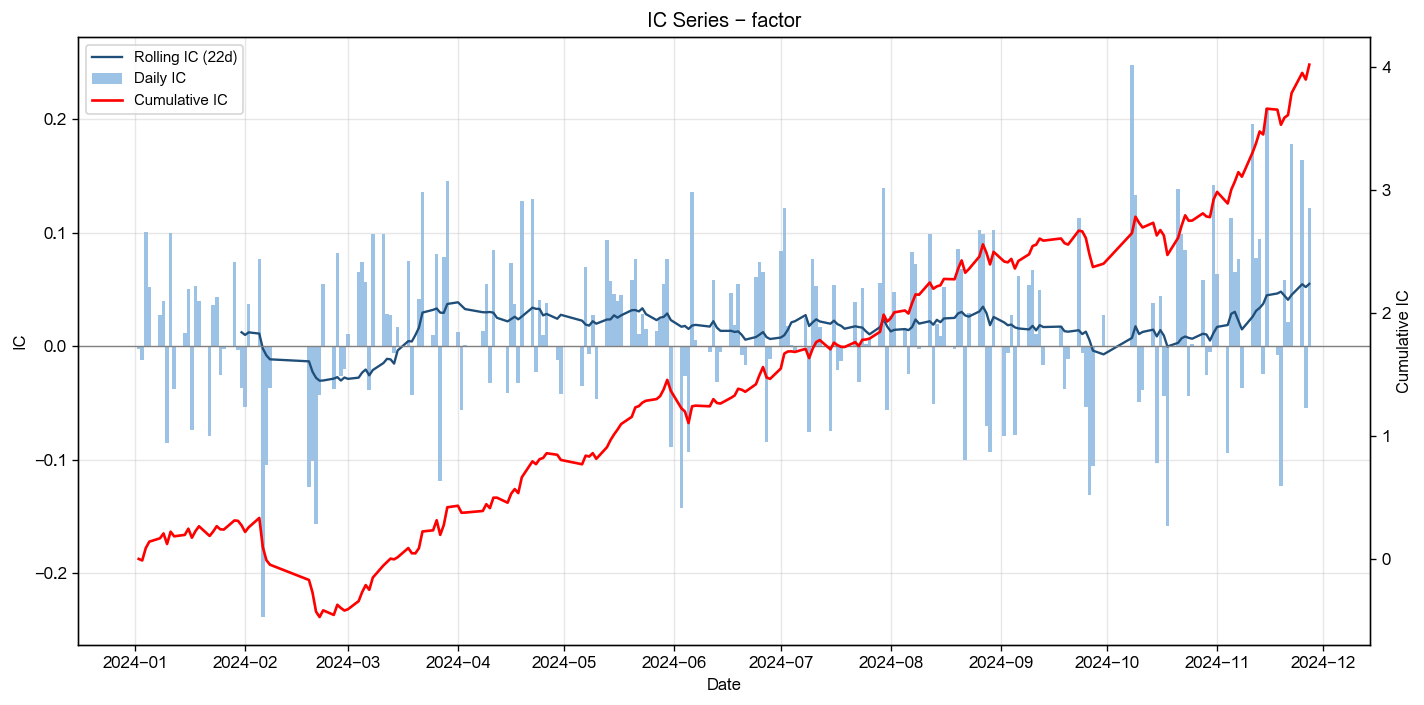
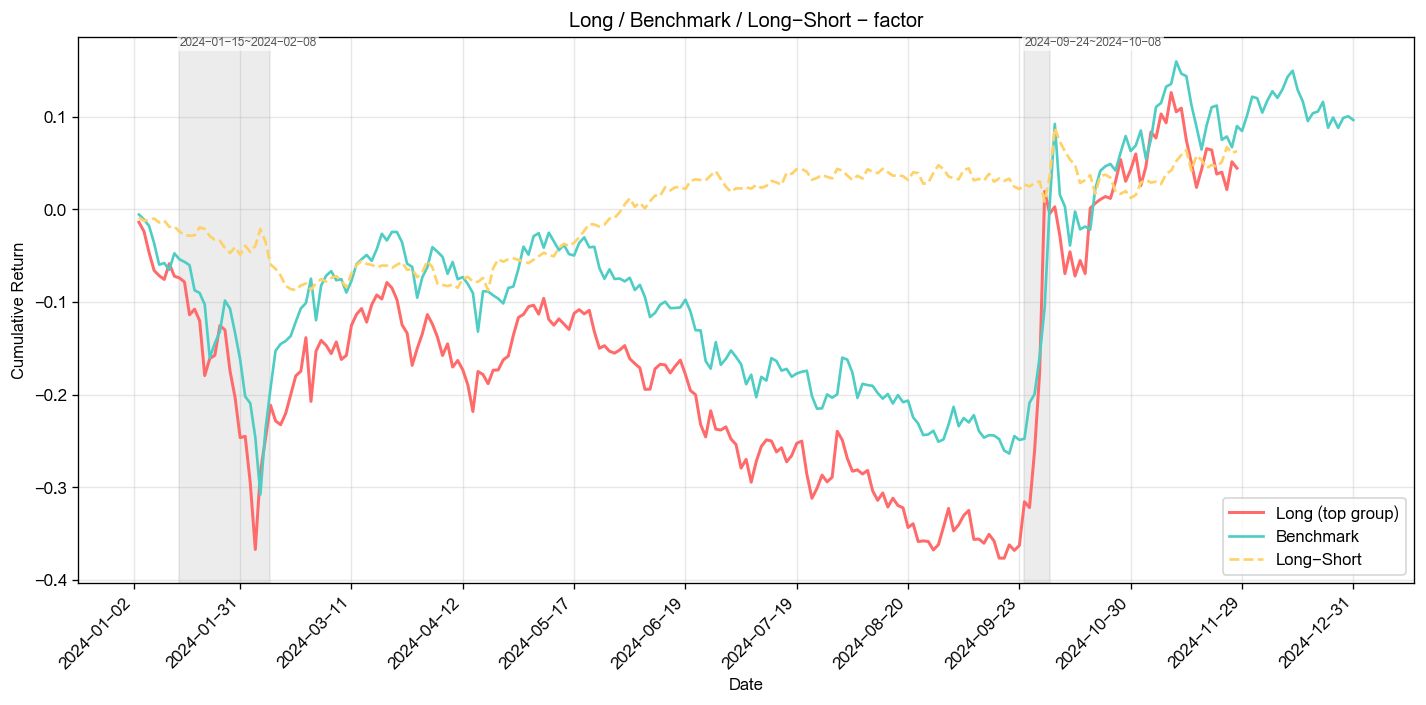
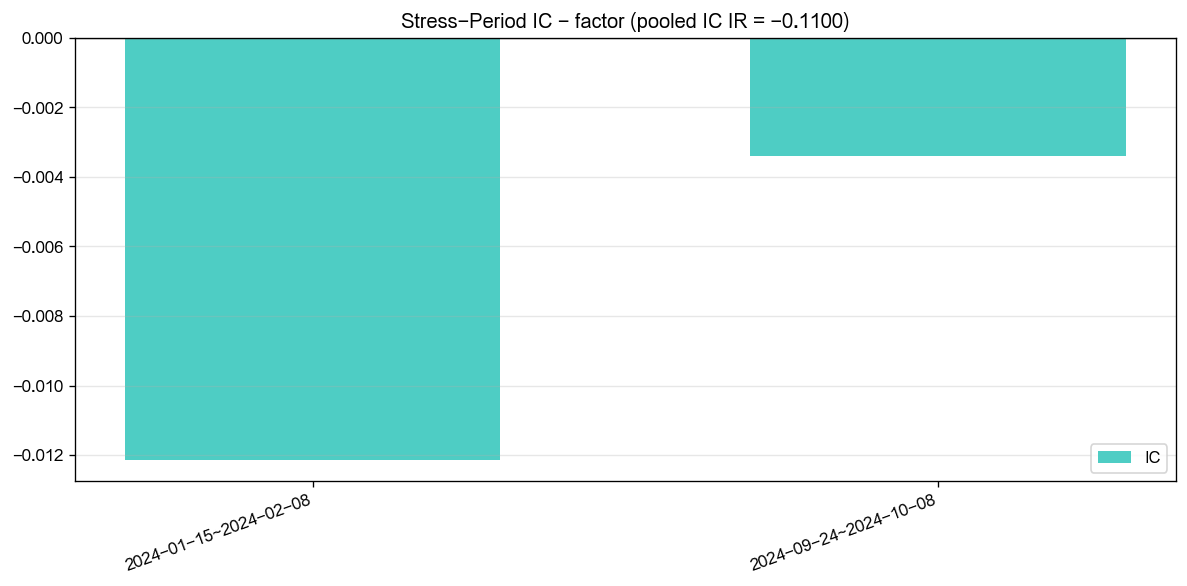
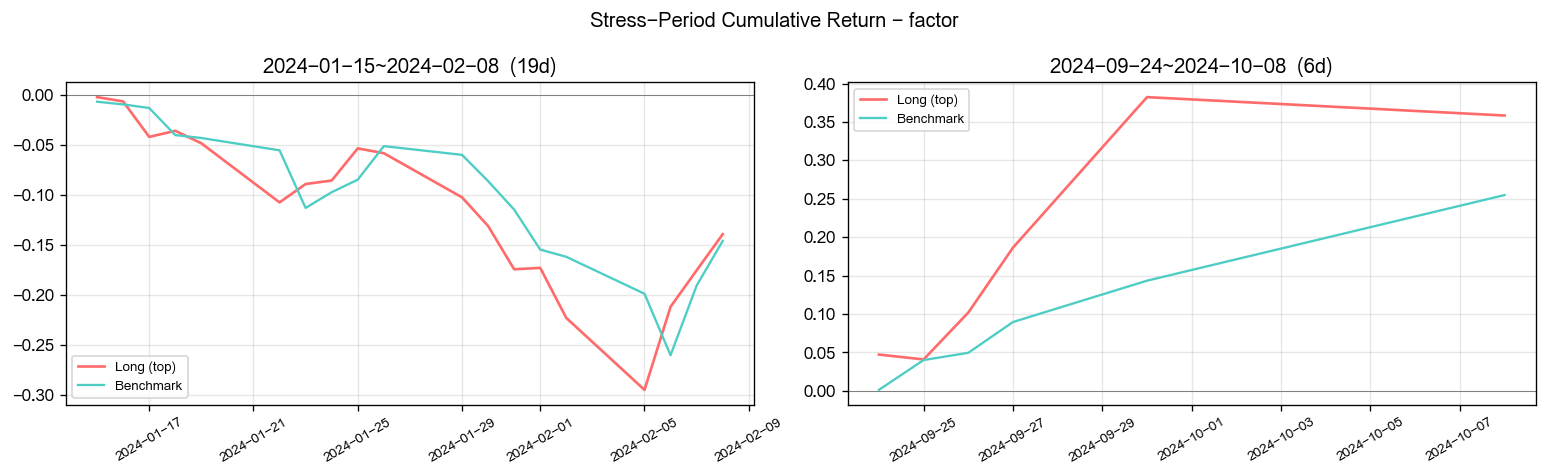

[2026-07-06 23:48:17] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-06 23:48:17] [warning  ] 返回的Outputs实例(size=35242694) 大于 64K, 将不会被缓存
[2026-07-06 23:48:17] [info     ] bigalpha_eval.v4 运行完成 [11.195s].


In [3]:
def main(datasources, start_date, end_date):
    """BigAlpha multi-scale raw Transformer submission.

    平台只替换 datasources / start_date / end_date。训练区间固定为样本外历史区间，
    start_date~end_date 只用于推理，避免数据泄漏。模型直接使用 1m/5m/15m/30m
    原始 K 线与盘口快照字段，每个频率单独编码后融合，输出每日股票 score。
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    import structlog

    logger = structlog.get_logger()

    # ---------- fixed config ----------
    TRAIN_START, TRAIN_END = "2019-01-01", "2023-12-31 23:59:59"
    VALID_START, VALID_END = "2024-01-01", "2024-12-31 23:59:59"
    EPOCHS, BATCH, LR, SEED = 4, 512, 8e-4, 42
    MAX_TRAIN_INSTRUMENTS = 120
    MAX_VALID_INSTRUMENTS = 300
    INFER_CHUNK_SIZE = 200
    BUFFER_DAYS = 45
    TOP_RANK_PCT = 0.95
    TOP_LABEL_WEIGHT = 2.0

    STREAMS = [
        ("bar1m", "bigalpha_2026_stock_bar1m", 32),
        ("bar5m", "bigalpha_2026_stock_bar5m", 32),
        ("bar15m", "bigalpha_2026_stock_bar15m", 24),
        ("bar30m", "bigalpha_2026_stock_bar30m", 24),
    ]
    STREAM_NAMES = [x[0] for x in STREAMS]
    SEQ_LENS = [x[2] for x in STREAMS]

    PRICE_COLS = ["open", "high", "low", "close", "bid_price1", "ask_price1"]
    VOL_COLS = ["volume", "amount", "deal_number", "bid_volume1", "ask_volume1", "bid_num_orders1", "ask_num_orders1"]
    FEATURE_COLS = PRICE_COLS + VOL_COLS
    N_FEAT = len(FEATURE_COLS)

    np.random.seed(SEED)
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def table_for(key, default):
        return datasources.get(key) or datasources.get(key.replace("bar", "bar_")) or default

    def log_info(msg, **kwargs):
        try:
            logger.info(msg, **kwargs)
        except Exception:
            print(msg, kwargs)

    def available_columns(table, sd, ed):
        try:
            sample = dai.query(f"SELECT * FROM {table} LIMIT 1", filters={"date": [sd, ed]}).df()
            return set(sample.columns)
        except Exception:
            return {"date", "instrument", *FEATURE_COLS}

    def query_raw(table, sd, ed, instruments):
        cols = available_columns(table, sd, ed)
        fields = [c for c in FEATURE_COLS if c in cols]
        select_cols = ["date", "instrument", *fields]
        sql = f"SELECT {', '.join(select_cols)} FROM {table} ORDER BY instrument, date"
        filters = {"date": [sd, ed]}
        if instruments is not None:
            filters["instrument"] = list(instruments)
        df = dai.query(sql, filters=filters, compression=True).df()
        for c in FEATURE_COLS:
            if c not in df.columns:
                df[c] = np.nan
        return df[["date", "instrument", *FEATURE_COLS]]

    def pool(sd, ed, distinct=True):
        if distinct:
            sql = "SELECT DISTINCT instrument FROM bigalpha_2026_instruments"
            df = dai.query(sql, filters={"date": [sd, ed]}).df()
            return df["instrument"].astype(str).drop_duplicates().tolist()
        df = dai.query(
            "SELECT date, instrument FROM bigalpha_2026_instruments",
            filters={"date": [sd, ed]},
        ).df()
        df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
        df["instrument"] = df["instrument"].astype(str)
        return df.dropna(subset=["date", "instrument"]).drop_duplicates(["date", "instrument"])

    def build_stream(table, sd, ed, mode, instruments, seq_len, stats=None):
        t0 = time.time()
        buf = (pd.to_datetime(sd) - pd.Timedelta(days=BUFFER_DAYS)).strftime("%Y-%m-%d %H:%M:%S")
        raw = query_raw(table, buf, ed, instruments)
        if raw.empty:
            raise RuntimeError(f"no raw data for {table} {sd}~{ed}")

        raw = raw.copy()
        raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
        raw["instrument"] = raw["instrument"].astype(str)
        raw = raw.dropna(subset=["date", "instrument"]).sort_values(["instrument", "date"])
        for c in FEATURE_COLS:
            raw[c] = pd.to_numeric(raw[c], errors="coerce")
        for c in VOL_COLS:
            raw[c] = np.log1p(raw[c].clip(lower=0))

        sd_ts, ed_ts = pd.to_datetime(sd), pd.to_datetime(ed)
        wins, labels, keys = [], [], []
        for ins, sub in raw.groupby("instrument", sort=False):
            if len(sub) < seq_len:
                continue
            feats = sub[FEATURE_COLS].to_numpy(np.float32)
            days = sub["date"].dt.normalize().to_numpy()
            close_pos = np.flatnonzero(np.append(days[1:] != days[:-1], True))
            close_px = sub["close"].to_numpy(np.float64)[close_pos]
            dates = days[close_pos]
            for k, p in enumerate(close_pos):
                d = pd.Timestamp(dates[k])
                if p + 1 < seq_len or d < sd_ts or d > ed_ts:
                    continue
                label = np.nan
                if k + 1 < len(close_pos) and close_px[k] > 0:
                    r = close_px[k + 1] / close_px[k] - 1.0
                    if np.isfinite(r):
                        label = np.float32(r)
                if mode == "train" and not np.isfinite(label):
                    continue
                wins.append(feats[p - seq_len + 1:p + 1])
                labels.append(label)
                keys.append((d, ins))

        if not keys:
            raise RuntimeError(f"build_stream no samples table={table} mode={mode}")

        x = np.stack(wins).astype(np.float32)
        if stats is None:
            flat = x.reshape(-1, N_FEAT)
            mean = np.nanmean(flat, axis=0).astype(np.float32)
            mean = np.where(np.isfinite(mean), mean, 0.0).astype(np.float32)
            flat = np.where(np.isfinite(flat), flat, mean)
            std = flat.std(axis=0).astype(np.float32) + 1e-6
            stats = (mean, std)
        mean, std = stats
        x = np.where(np.isfinite(x), x, mean)
        x = ((x - mean) / std).astype(np.float32)
        idx = pd.DataFrame(keys, columns=["date", "instrument"])
        y = np.asarray(labels, dtype=np.float32)
        log_info("stream built", table=table, mode=mode, samples=len(idx), seq_len=seq_len,
                 elapsed=round(time.time() - t0, 2))
        return idx, x, y, stats

    def align_streams(stream_payloads, mode):
        key_sets = []
        for idx, _, _, _ in stream_payloads:
            key_sets.append(set(zip(idx["date"], idx["instrument"])))
        common = set.intersection(*key_sets)
        if not common:
            raise RuntimeError(f"no aligned multi-scale samples mode={mode}")
        ordered = sorted(common, key=lambda z: (z[0], z[1]))
        out_idx = pd.DataFrame(ordered, columns=["date", "instrument"])
        xs = []
        y = None
        for i, (idx, x, labels, _) in enumerate(stream_payloads):
            pos = {k: j for j, k in enumerate(zip(idx["date"], idx["instrument"]))}
            take = np.asarray([pos[k] for k in ordered], dtype=np.int64)
            xs.append(x[take])
            if i == 0:
                y = labels[take]
        return out_idx, xs, y

    def rank_labels(idx, y):
        df = idx.copy()
        df["target"] = y.astype(np.float64)
        df["target"] = df["target"].replace([np.inf, -np.inf], np.nan)
        df = df.dropna(subset=["target"]).reset_index(drop=True)
        grouped = df.groupby("date")["target"]
        rank = grouped.rank(method="average", ascending=True).astype(np.float64)
        rank_count = df.groupby("date")["target"].transform("count").astype(np.float64)
        rank_mean = rank.groupby(df["date"]).transform("mean")
        rank_std = rank.groupby(df["date"]).transform(lambda s: s.std(ddof=0)).replace(0.0, np.nan)
        label = ((rank - rank_mean) / rank_std).replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
        rank_pct = rank / rank_count.clip(lower=1.0)
        weights = np.where(rank_pct >= TOP_RANK_PCT, TOP_LABEL_WEIGHT, 1.0).astype(np.float32)
        return df[["date", "instrument"]].reset_index(drop=True), label.to_numpy(np.float32), weights

    def build_multistream(sd, ed, mode, instruments, stats_by_stream=None):
        payloads, next_stats = [], {}
        for key, default, seq_len in STREAMS:
            table = table_for(key, default)
            stats = None if stats_by_stream is None else stats_by_stream[key]
            item = build_stream(table, sd, ed, mode, instruments, seq_len, stats)
            payloads.append(item)
            next_stats[key] = item[3]
        idx, xs, y = align_streams(payloads, mode)
        weights = None
        if mode == "train":
            aligned_keys = list(zip(idx["date"], idx["instrument"]))
            idx, y, weights = rank_labels(idx, y)
            keep = set(zip(idx["date"], idx["instrument"]))
            take = np.asarray([i for i, k in enumerate(aligned_keys) if k in keep], dtype=np.int64)
            xs = [x[take] for x in xs]
        return idx, xs, y, weights, next_stats

    class StreamEncoder(nn.Module):
        def __init__(self, n_feat, seq_len, d_model=96, nhead=4, nlayers=1, dim_ff=192):
            super().__init__()
            self.proj = nn.Linear(n_feat, d_model)
            self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
            layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_ff,
                dropout=0.1,
                batch_first=True,
                activation="gelu",
            )
            self.encoder = nn.TransformerEncoder(layer, nlayers)

        def forward(self, x):
            h = self.proj(x) + self.pos[:, :x.size(1), :]
            return self.encoder(h).mean(dim=1)

    class MultiScaleTransformer(nn.Module):
        def __init__(self, n_feat, seq_lens, d_model=96):
            super().__init__()
            self.encoders = nn.ModuleList([StreamEncoder(n_feat, seq_len, d_model=d_model) for seq_len in seq_lens])
            fusion_dim = d_model * len(seq_lens)
            self.fusion = nn.Sequential(
                nn.LayerNorm(fusion_dim),
                nn.Linear(fusion_dim, d_model * 2),
                nn.GELU(),
                nn.Dropout(0.1),
                nn.Linear(d_model * 2, d_model),
                nn.GELU(),
            )
            self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

        def forward(self, *xs):
            h = torch.cat([enc(x) for enc, x in zip(self.encoders, xs)], dim=-1)
            return self.head(self.fusion(h)).squeeze(-1)

    def predict_in_batches(model, xs, batch_size):
        model.eval()
        tensors = [torch.from_numpy(x) for x in xs]
        preds = []
        with torch.no_grad():
            n = len(tensors[0])
            for i in range(0, n, batch_size):
                xb = [t[i:i + batch_size].to(device, non_blocking=True) for t in tensors]
                preds.append(model(*xb).cpu().numpy())
        return np.concatenate(preds).astype(np.float64)

    # ---------- train ----------
    log_info("device", device=str(device), streams=STREAM_NAMES)
    train_instruments = pool(TRAIN_START, TRAIN_END)[:MAX_TRAIN_INSTRUMENTS]
    log_info("building train set", instruments=len(train_instruments), start=TRAIN_START, end=TRAIN_END)
    train_idx, train_xs, ytr, wtr, stats_by_stream = build_multistream(
        TRAIN_START, TRAIN_END, "train", train_instruments, None,
    )
    ytr = ytr.astype(np.float32)
    wtr = wtr.astype(np.float32)

    model = MultiScaleTransformer(N_FEAT, SEQ_LENS).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    top_rank_ratio = float(np.mean(wtr > 1.0))
    log_info("model ready", train_samples=len(ytr), n_params=n_params,
             label_mode="daily_rank_zscore", top_rank_pct=TOP_RANK_PCT,
             top_label_weight=TOP_LABEL_WEIGHT, top_rank_ratio=round(top_rank_ratio, 4))

    tensors = [torch.from_numpy(x) for x in train_xs] + [torch.from_numpy(ytr), torch.from_numpy(wtr)]
    loader = DataLoader(TensorDataset(*tensors), batch_size=BATCH, shuffle=True,
                        pin_memory=(device.type == "cuda"))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss(beta=0.2, reduction="none")
    model.train()
    for ep in range(EPOCHS):
        t0, total, nb = time.time(), 0.0, 0
        for batch in loader:
            xs = [b.to(device, non_blocking=True) for b in batch[:-2]]
            yb = batch[-2].to(device, non_blocking=True)
            wb = batch[-1].to(device, non_blocking=True)
            opt.zero_grad()
            pred = model(*xs)
            sample_loss = loss_fn(pred, yb)
            loss = (sample_loss * wb).sum() / wb.sum().clamp_min(1e-6)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += float(loss.item())
            nb += 1
        log_info("epoch done", epoch=ep + 1, loss=round(total / max(nb, 1), 8),
                 elapsed=round(time.time() - t0, 2))

    # ---------- validate on 2024 ----------
    valid_instruments = pool(VALID_START, VALID_END)[:MAX_VALID_INSTRUMENTS]
    log_info("building validation set", instruments=len(valid_instruments), start=VALID_START, end=VALID_END)
    try:
        valid_idx, valid_xs, yva, _, _ = build_multistream(
            VALID_START, VALID_END, "train", valid_instruments, stats_by_stream,
        )
        valid_pred = predict_in_batches(model, valid_xs, BATCH)
        valid_mse = float(np.mean((valid_pred - yva.astype(np.float64)) ** 2))
        ic_values = []
        tmp = valid_idx.copy()
        tmp["pred"] = valid_pred
        tmp["label"] = yva.astype(np.float64)
        for _, g in tmp.groupby("date"):
            if len(g) >= 5 and g["pred"].nunique() > 1 and g["label"].nunique() > 1:
                ic = g["pred"].corr(g["label"], method="spearman")
                if np.isfinite(ic):
                    ic_values.append(float(ic))
        valid_rank_ic = float(np.mean(ic_values)) if ic_values else np.nan
        log_info("validation done", samples=len(yva), days=valid_idx["date"].nunique(),
                 mse=round(valid_mse, 8), rank_ic=round(valid_rank_ic, 6) if np.isfinite(valid_rank_ic) else None)
    except Exception as exc:
        log_info("validation skipped", error=str(exc))

    # ---------- infer in chunks ----------
    test_pool = pool(start_date, end_date, distinct=False)
    instruments = test_pool["instrument"].drop_duplicates().tolist()
    pred_parts = []
    for start in range(0, len(instruments), INFER_CHUNK_SIZE):
        chunk = instruments[start:start + INFER_CHUNK_SIZE]
        log_info("infer chunk", chunk_start=start, chunk_size=len(chunk))
        try:
            idx, xs, _, _, _ = build_multistream(start_date, end_date, "infer", chunk, stats_by_stream)
            idx = idx.copy()
            idx["score"] = predict_in_batches(model, xs, BATCH)
            pred_parts.append(idx)
        except Exception as exc:
            log_info("infer chunk skipped", chunk_start=start, error=str(exc))

    if pred_parts:
        pred = pd.concat(pred_parts, ignore_index=True)
        pred["date"] = pd.to_datetime(pred["date"], errors="coerce").dt.normalize()
        pred["instrument"] = pred["instrument"].astype(str)
        pred = pred.dropna(subset=["date", "instrument"]).drop_duplicates(["date", "instrument"], keep="last")
    else:
        pred = pd.DataFrame(columns=["date", "instrument", "score"])

    result = test_pool.merge(pred, on=["date", "instrument"], how="left")
    result["score"] = pd.to_numeric(result["score"], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    result = result.sort_values(["date", "instrument"]).reset_index(drop=True)
    log_info("score finished", rows=len(result), days=result["date"].nunique(),
             instruments=result["instrument"].nunique())
    return result[["date", "instrument", "score"]]


if __name__ == "__main__":
    from bigmodule import M
    import structlog

    logger = structlog.get_logger()
    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
        "bar5m": "bigalpha_2026_stock_bar5m",
        "bar15m": "bigalpha_2026_stock_bar15m",
        "bar30m": "bigalpha_2026_stock_bar30m",
    }
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    logger.info("calculate score", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
